In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/online_retail_II.csv")

In [7]:
# Display first 5 rows
df.head()

# Show structure of dataset (columns, data types, null values)
df.info()

# Get statistical summary of numerical columns
df.describe()

# Check how many missing values exist in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129786 entries, 0 to 129785
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      129786 non-null  object 
 1   StockCode    129786 non-null  object 
 2   Description  128628 non-null  object 
 3   Quantity     129786 non-null  int64  
 4   InvoiceDate  129786 non-null  object 
 5   Price        129786 non-null  float64
 6   Customer ID  96634 non-null   float64
 7   Country      129785 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ MB


,0
Invoice,0
StockCode,0
Description,1158
Quantity,0
InvoiceDate,0
Price,0
Customer ID,33152
Country,1


In [8]:
# Remove rows where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

In [9]:
# Remove rows where Invoice starts with letter 'C'
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [10]:
# Create a new column that calculates revenue per row
# Total Sales = Quantity × Price
df['Total_Sales'] = df['Quantity'] * df['Price']

In [11]:
# Calculate total revenue of entire dataset
total_revenue = df['Total_Sales'].sum()

# Print result
print("Total Revenue:", total_revenue)

Total Revenue: 2137216.819


In [12]:
# Group by product description
# Sum total sales
# Sort descending
# Take top 10
top_products = (
    df.groupby('Description')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    44596.43
Manual                                22057.25
JUMBO BAG RED WHITE SPOTTY            20707.65
EDWARDIAN PARASOL BLACK               15769.85
ASSORTED COLOUR BIRD ORNAMENT         15558.54
RETRO SPOT CAKE STAND                 13089.90
EDWARDIAN PARASOL NATURAL             12217.40
EDWARDIAN PARASOL RED                 12187.25
 WHITE CHERRY LIGHTS                  11418.00
DOOR MAT UNION FLAG                   10801.86
Name: Total_Sales, dtype: float64


In [13]:
# Group by product description
# Sum quantity
# Sort descending
# Take top 10
top_quantity = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_quantity)

Description
BLACK AND WHITE PAISLEY FLOWER MUG    25631
WHITE HANGING HEART T-LIGHT HOLDER    16759
PACK OF 72 RETRO SPOT CAKE CASES      15954
SET/6 WOODLAND PAPER PLATES           13668
SET/6 WOODLAND PAPER CUPS             13632
SET/6 STRAWBERRY PAPER CUPS           13304
SET/6 STRAWBERRY PAPER PLATES         12806
SMALL FAIRY CAKE FRIDGE MAGNETS       12236
JUMBO BAG RED WHITE SPOTTY            11863
JAZZ HEARTS MEMO PAD                  10945
Name: Quantity, dtype: int64


In [14]:
# Group by Customer ID
# Sum total revenue
# Sort descending
# Get top 10
top_customers = (
    df.groupby('Customer ID')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer ID
18102.0    114492.84
14156.0     81489.95
14646.0     75187.48
13694.0     62908.90
14911.0     35344.19
13902.0     34095.26
15311.0     26676.40
17949.0     21707.52
17511.0     21046.04
17850.0     19419.68
Name: Total_Sales, dtype: float64


In [15]:
# Group by country and calculate total revenue
country_sales = (
    df.groupby('Country')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)

print(country_sales)

Country
United Kingdom          1763036.749
EIRE                     119073.730
Netherlands               76442.690
Germany                   43699.360
Denmark                   36713.340
France                    31483.240
Spain                     13489.050
Sweden                    11252.030
Belgium                    6194.640
Greece                     5932.030
Cyprus                     5221.970
Portugal                   4031.810
Austria                    3465.520
USA                        2430.590
United Arab Emirates       1828.000
Channel Islands            1827.930
Australia                  1695.350
Switzerland                1674.760
Malta                      1636.380
Finland                    1350.500
Italy                      1196.240
Unspecified                1035.100
RSA                         931.430
Poland                      690.680
Norway                      485.310
Japan                       307.070
Nigeria                      27.820
Name: Total_Sales, d

In [16]:
# First calculate total revenue per invoice
order_revenue = df.groupby('Invoice')['Total_Sales'].sum()

# Then calculate average order value
average_order_value = order_revenue.mean()

print("Average Order Value:", average_order_value)

Average Order Value: 475.3596127669039


/tmp/ipython-input-3492387571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


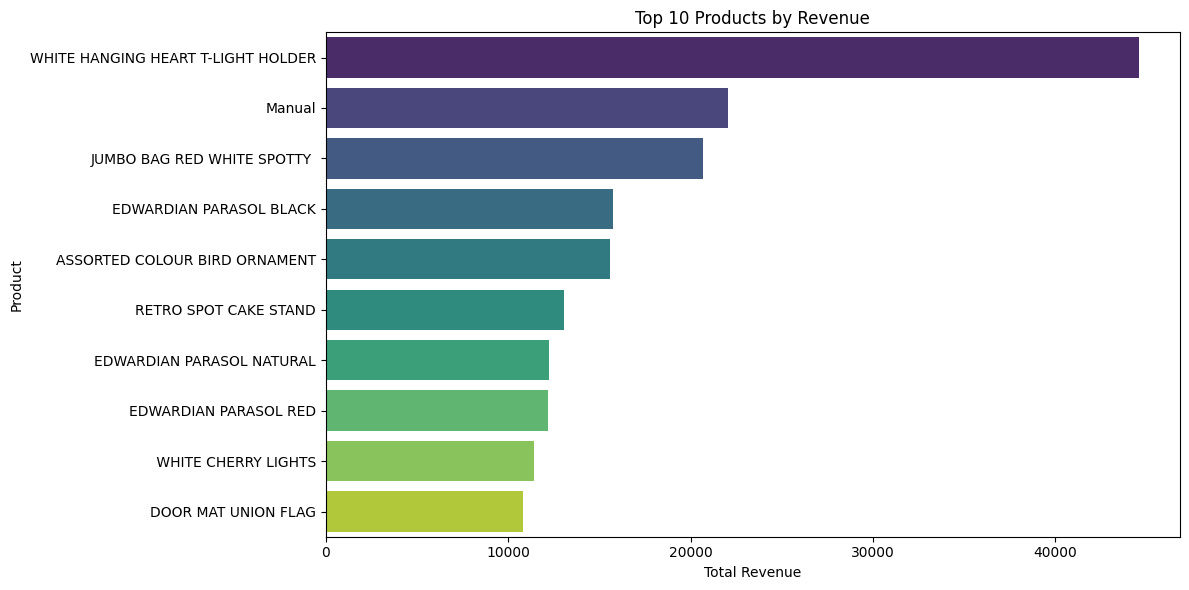

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2228169343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_quantity.values, y=top_quantity.index, palette="magma")


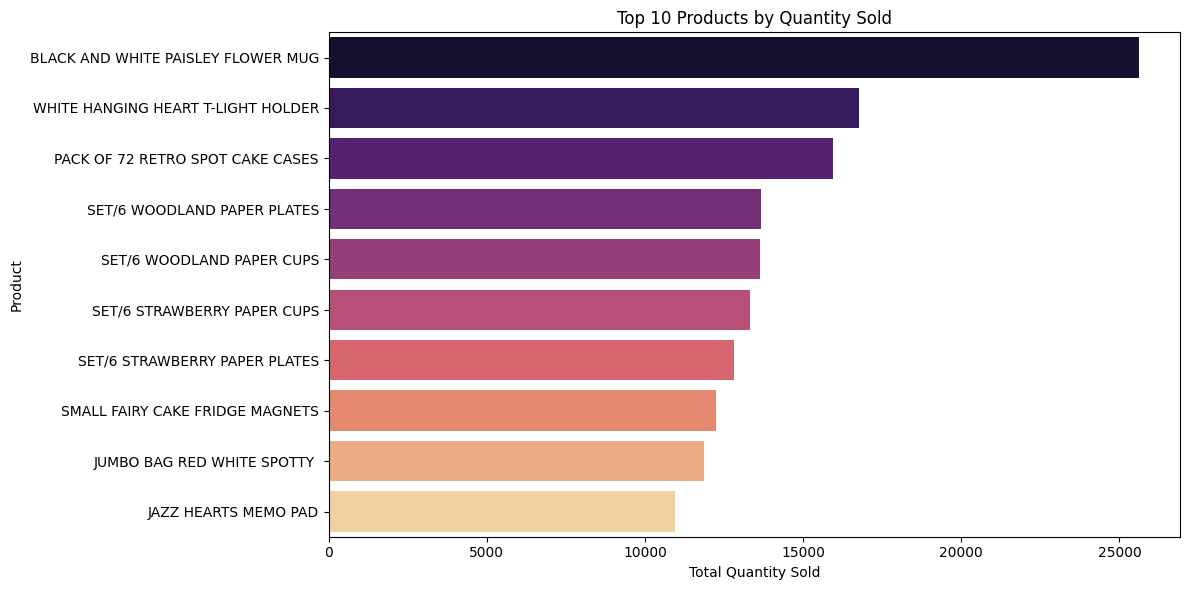

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_quantity.values, y=top_quantity.index, palette="magma")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3897485555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette="coolwarm")


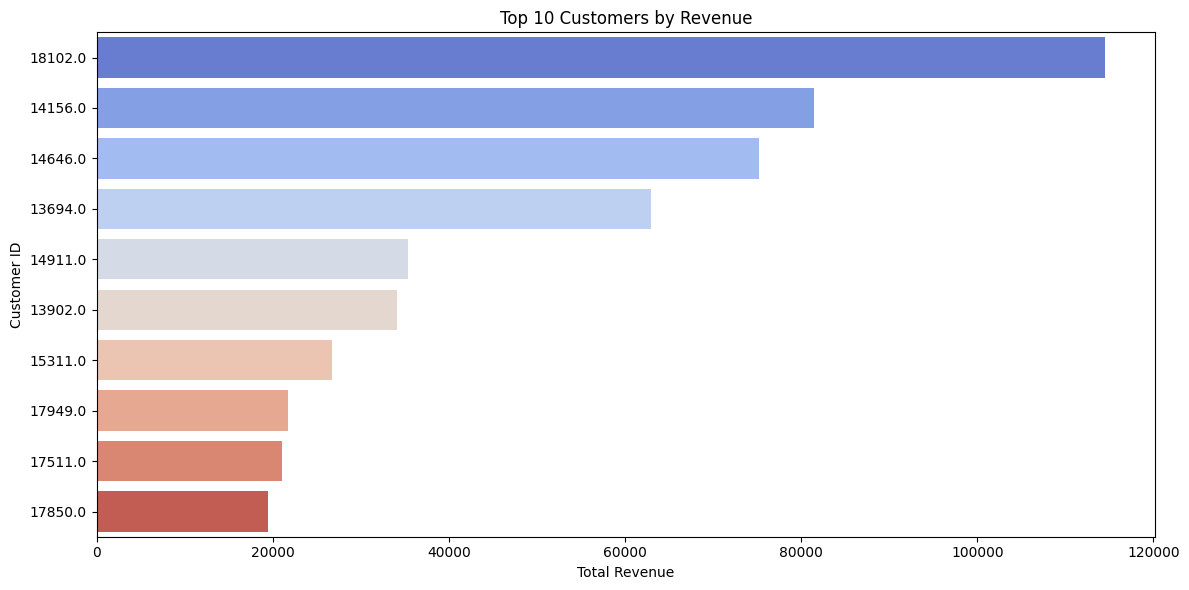

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette="coolwarm")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1842599803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="Set2")


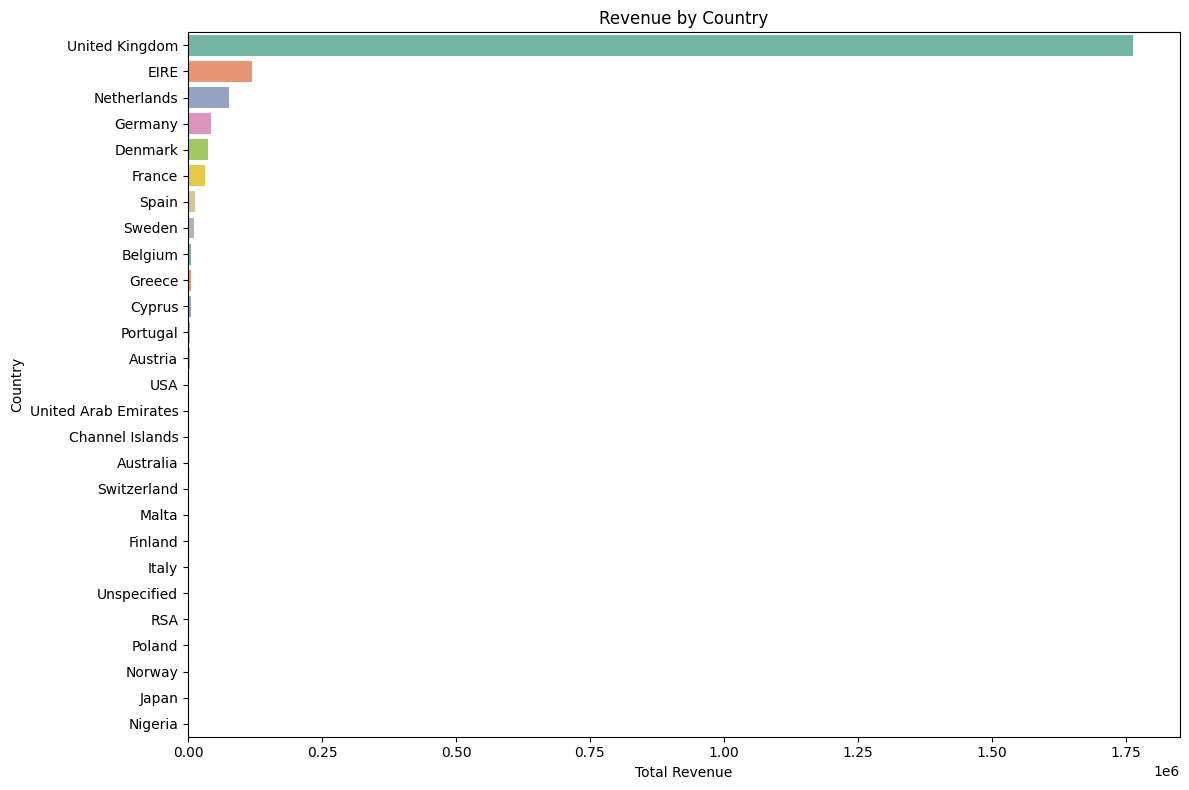

In [20]:
plt.figure(figsize=(12,8))
sns.barplot(x=country_sales.values, y=country_sales.index, palette="Set2")
plt.title("Revenue by Country")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

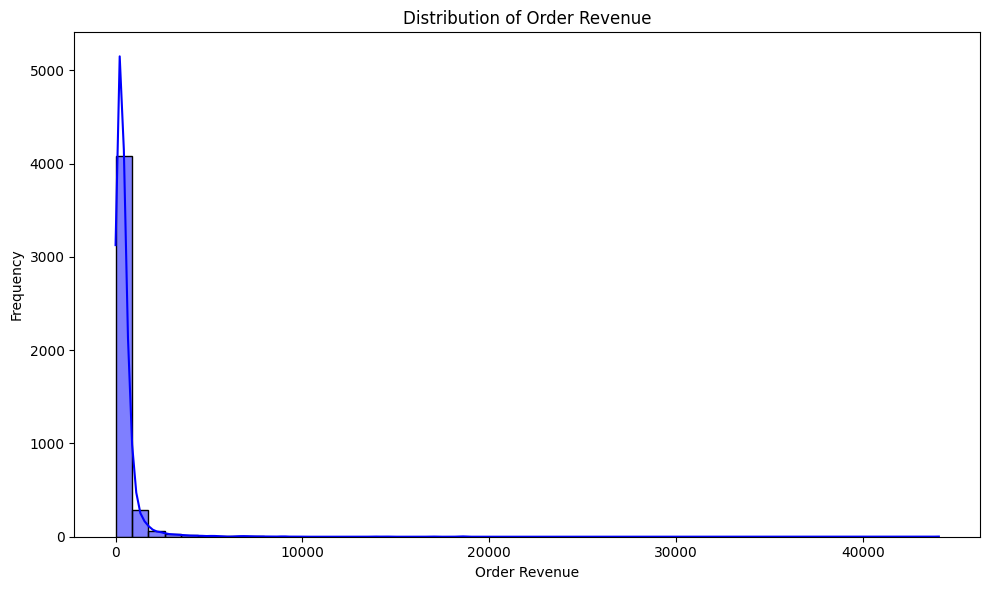

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(order_revenue, bins=50, kde=True, color="blue")
plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()